# Chapter 7.1: Reinforcement Learning for Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the exploration-exploitation trade-off in recommendation systems
2. Implement epsilon-greedy, UCB, and Thompson Sampling contextual bandits
3. Formulate recommendation as a Markov Decision Process (MDP)
4. Build a DQN agent where state=user history and action=item selection
5. Implement REINFORCE policy gradient for ranking optimization
6. Evaluate RL policies using off-policy evaluation (OPE) with importance sampling
7. Compare bandit and full RL approaches for different recommendation scenarios

## Prerequisites

- Probability and statistics (Bayes' theorem, Beta distribution)
- Basic neural networks (PyTorch fundamentals)
- Understanding of recommendation system basics (Parts 1-3)
- Familiarity with reward-based optimization

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part7/chapter_7.1_rl_rec.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part7/chapter_7.1_rl_rec.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import deque, namedtuple
import random
from typing import List, Tuple, Dict

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

plt.style.use('seaborn-v0_8')
print("All imports successful.")

All imports successful.


## 1. The Exploration-Exploitation Dilemma in Recommendation

Traditional recommendation systems greedily recommend items predicted to have the highest rating or CTR. However, this **exploitation-only** strategy leads to:

- **Filter bubbles**: Users only see items similar to what they already liked
- **Cold-start stagnation**: New items never get recommended
- **Suboptimal long-term engagement**: Missing potentially great items

**Reinforcement Learning (RL)** frames recommendation as a sequential decision problem where the system must balance:

$$\text{Total Reward} = \sum_{t=1}^{T} \gamma^{t-1} r_t$$

where $r_t$ is the reward (click, rating, purchase) at time $t$ and $\gamma$ is the discount factor.

> **💡 Concept:** The **multi-armed bandit** (MAB) is the simplest RL formulation for recommendation. Each item is an "arm" and pulling an arm means recommending that item. The challenge is to maximize cumulative reward over time without knowing the true reward distributions.

## 2. Multi-Armed Bandits for Recommendation

We start with the basic MAB setting, then extend to contextual bandits.

### Problem Setup

- $K$ items (arms) to recommend
- Each item $k$ has an unknown reward distribution with mean $\mu_k$
- At each round $t$, the agent selects an item $a_t$ and observes reward $r_t$
- **Regret**: $R_T = \sum_{t=1}^{T} (\mu^* - \mu_{a_t})$ where $\mu^* = \max_k \mu_k$

In [2]:
class RecommendationBanditEnv:
    """Simulated recommendation environment with K items."""
    
    def __init__(self, n_items: int = 10, seed: int = 42):
        self.rng = np.random.RandomState(seed)
        self.n_items = n_items
        # True click-through rates for each item
        self.true_ctrs = self.rng.beta(2, 5, size=n_items)
        self.best_arm = np.argmax(self.true_ctrs)
        self.best_ctr = self.true_ctrs[self.best_arm]
        print(f"Environment: {n_items} items, best CTR = {self.best_ctr:.4f} (item {self.best_arm})")
    
    def pull(self, arm: int) -> float:
        """Recommend an item and observe binary click/no-click."""
        return float(self.rng.random() < self.true_ctrs[arm])


class EpsilonGreedy:
    """Epsilon-greedy bandit for recommendation."""
    
    def __init__(self, n_items: int, epsilon: float = 0.1):
        self.n_items = n_items
        self.epsilon = epsilon
        self.counts = np.zeros(n_items)
        self.values = np.zeros(n_items)
    
    def select_arm(self) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_items)
        return int(np.argmax(self.values))
    
    def update(self, arm: int, reward: float):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] = self.values[arm] * (n - 1) / n + reward / n


class UCB1:
    """Upper Confidence Bound bandit (Auer et al., 2002)."""
    
    def __init__(self, n_items: int, c: float = 2.0):
        self.n_items = n_items
        self.c = c
        self.counts = np.zeros(n_items)
        self.values = np.zeros(n_items)
        self.total_count = 0
    
    def select_arm(self) -> int:
        # Play each arm once first
        for i in range(self.n_items):
            if self.counts[i] == 0:
                return i
        
        ucb_values = self.values + self.c * np.sqrt(
            np.log(self.total_count) / self.counts
        )
        return int(np.argmax(ucb_values))
    
    def update(self, arm: int, reward: float):
        self.total_count += 1
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] = self.values[arm] * (n - 1) / n + reward / n


class ThompsonSampling:
    """Thompson Sampling for Bernoulli bandits (Thompson, 1933; Chapelle & Li, 2011)."""
    
    def __init__(self, n_items: int):
        self.n_items = n_items
        # Beta prior: alpha=1, beta=1 (uniform)
        self.alphas = np.ones(n_items)
        self.betas = np.ones(n_items)
    
    def select_arm(self) -> int:
        samples = np.random.beta(self.alphas, self.betas)
        return int(np.argmax(samples))
    
    def update(self, arm: int, reward: float):
        if reward > 0:
            self.alphas[arm] += 1
        else:
            self.betas[arm] += 1


env = RecommendationBanditEnv(n_items=10, seed=42)

Environment: 10 items, best CTR = 0.5503 (item 4)


Environment: 10 items, best CTR = 0.5503 (item 4)
Epsilon-Greedy (0.1)           | Final regret: 245.1 | Avg reward (last 1k): 0.5280
Environment: 10 items, best CTR = 0.5503 (item 4)


Epsilon-Greedy (0.01)          | Final regret: 975.0 | Avg reward (last 1k): 0.3680
Environment: 10 items, best CTR = 0.5503 (item 4)


UCB1                           | Final regret: 476.5 | Avg reward (last 1k): 0.4960


Environment: 10 items, best CTR = 0.5503 (item 4)


Thompson Sampling              | Final regret: 84.0 | Avg reward (last 1k): 0.5420


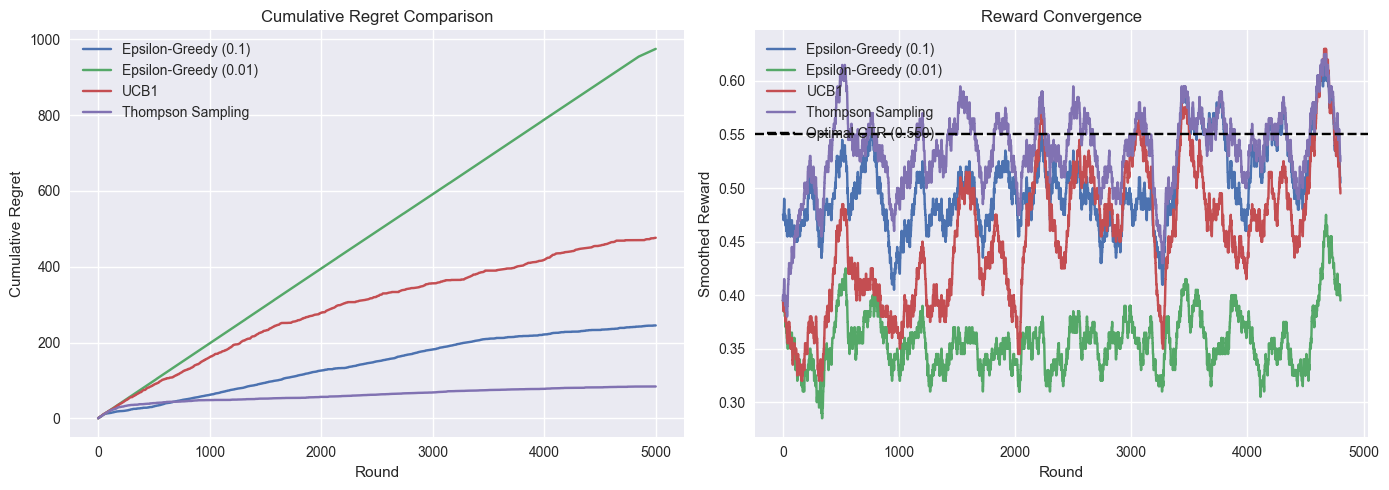

In [3]:
def run_bandit_experiment(env, agent, n_rounds: int = 5000):
    """Run a bandit experiment and track cumulative regret."""
    rewards = []
    regrets = []
    cumulative_regret = 0.0
    
    for t in range(n_rounds):
        arm = agent.select_arm()
        reward = env.pull(arm)
        agent.update(arm, reward)
        
        regret = env.best_ctr - env.true_ctrs[arm]
        cumulative_regret += regret
        rewards.append(reward)
        regrets.append(cumulative_regret)
    
    return rewards, regrets


# Run experiments
n_rounds = 5000
results = {}

for name, AgentClass, kwargs in [
    ("Epsilon-Greedy (0.1)", EpsilonGreedy, {"epsilon": 0.1}),
    ("Epsilon-Greedy (0.01)", EpsilonGreedy, {"epsilon": 0.01}),
    ("UCB1", UCB1, {"c": 2.0}),
    ("Thompson Sampling", ThompsonSampling, {}),
]:
    env_run = RecommendationBanditEnv(n_items=10, seed=42)
    agent = AgentClass(n_items=10, **kwargs)
    rewards, regrets = run_bandit_experiment(env_run, agent, n_rounds)
    results[name] = {"rewards": rewards, "regrets": regrets}
    avg_reward = np.mean(rewards[-1000:])
    print(f"{name:30s} | Final regret: {regrets[-1]:.1f} | Avg reward (last 1k): {avg_reward:.4f}")

# Plot cumulative regret
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results.items():
    axes[0].plot(data["regrets"], label=name)
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Cumulative Regret")
axes[0].set_title("Cumulative Regret Comparison")
axes[0].legend()

# Smoothed reward
window = 200
for name, data in results.items():
    smoothed = np.convolve(data["rewards"], np.ones(window)/window, mode='valid')
    axes[1].plot(smoothed, label=name)
axes[1].axhline(y=env.best_ctr, color='k', linestyle='--', label=f'Optimal CTR ({env.best_ctr:.3f})')
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Smoothed Reward")
axes[1].set_title("Reward Convergence")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Contextual Bandits for Recommendation

In real recommendation, we observe **context** $x_t$ (user features, time-of-day, etc.) before choosing an action. The expected reward depends on both context and action:

$$r_t = f(x_t, a_t) + \epsilon_t$$

This is the **contextual bandit** setting (Li et al., 2010 — LinUCB, Yahoo!).

> **💡 Concept:** Contextual bandits sit between MAB (no context) and full RL (sequential states). They are the most practical RL formulation for many recommendation scenarios because they don't require modeling state transitions.

In [4]:
class ContextualBanditEnv:
    """Contextual bandit environment: reward depends on user features + item."""
    
    def __init__(self, n_items: int = 10, context_dim: int = 5, seed: int = 42):
        self.rng = np.random.RandomState(seed)
        self.n_items = n_items
        self.context_dim = context_dim
        # True weight vectors for each item
        self.true_weights = self.rng.randn(n_items, context_dim) * 0.5
    
    def get_context(self) -> np.ndarray:
        """Generate a random user context."""
        return self.rng.randn(self.context_dim)
    
    def get_reward(self, context: np.ndarray, arm: int) -> float:
        """Get reward for recommending arm given context."""
        logit = context @ self.true_weights[arm]
        prob = 1.0 / (1.0 + np.exp(-logit))
        return float(self.rng.random() < prob)
    
    def best_arm(self, context: np.ndarray) -> int:
        """Oracle best arm for a given context."""
        logits = context @ self.true_weights.T
        probs = 1.0 / (1.0 + np.exp(-logits))
        return int(np.argmax(probs))
    
    def best_reward(self, context: np.ndarray) -> float:
        arm = self.best_arm(context)
        logit = context @ self.true_weights[arm]
        return 1.0 / (1.0 + np.exp(-logit))


class NeuralThompsonSampling:
    """Neural Thompson Sampling for contextual bandits.
    Uses a neural network with dropout as approximate posterior (Gal & Ghahramani, 2016).
    """
    
    def __init__(self, context_dim: int, n_items: int, hidden_dim: int = 32, lr: float = 0.01):
        self.n_items = n_items
        self.model = nn.Sequential(
            nn.Linear(context_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, n_items),
            nn.Sigmoid()
        )
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.buffer = []
        self.batch_size = 32
    
    def select_arm(self, context: np.ndarray) -> int:
        """Use MC Dropout for Thompson-like sampling."""
        self.model.train()  # Keep dropout active
        x = torch.FloatTensor(context).unsqueeze(0)
        with torch.no_grad():
            probs = self.model(x).squeeze(0).numpy()
        return int(np.argmax(probs))
    
    def update(self, context: np.ndarray, arm: int, reward: float):
        self.buffer.append((context, arm, reward))
        if len(self.buffer) >= self.batch_size:
            self._train()
    
    def _train(self):
        batch = random.sample(self.buffer, min(self.batch_size, len(self.buffer)))
        contexts = torch.FloatTensor(np.array([b[0] for b in batch]))
        arms = [b[1] for b in batch]
        rewards = torch.FloatTensor([b[2] for b in batch])
        
        self.model.train()
        preds = self.model(contexts)
        pred_rewards = preds[range(len(batch)), arms]
        loss = F.binary_cross_entropy(pred_rewards, rewards)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


# Run contextual bandit experiment
ctx_env = ContextualBanditEnv(n_items=10, context_dim=5, seed=42)
nts_agent = NeuralThompsonSampling(context_dim=5, n_items=10)

n_rounds = 3000
ctx_rewards = []
ctx_regrets = []
cum_regret = 0.0

for t in range(n_rounds):
    context = ctx_env.get_context()
    arm = nts_agent.select_arm(context)
    reward = ctx_env.get_reward(context, arm)
    nts_agent.update(context, arm, reward)
    
    best_r = ctx_env.best_reward(context)
    logit = context @ ctx_env.true_weights[arm]
    actual_prob = 1.0 / (1.0 + np.exp(-logit))
    cum_regret += best_r - actual_prob
    
    ctx_rewards.append(reward)
    ctx_regrets.append(cum_regret)

print(f"Neural Thompson Sampling - Final cumulative regret: {ctx_regrets[-1]:.1f}")
print(f"Average reward (last 500 rounds): {np.mean(ctx_rewards[-500:]):.4f}")

Neural Thompson Sampling - Final cumulative regret: 362.2
Average reward (last 500 rounds): 0.6820


## 4. DQN for Recommendation

For sequential recommendation, we model the problem as a full MDP:

- **State** $s_t$: User's interaction history (last $N$ items consumed)
- **Action** $a_t$: Item to recommend
- **Reward** $r_t$: User feedback (click, rating, dwell time)
- **Transition** $s_{t+1}$: Updated history after user interaction

The Q-function estimates the expected cumulative reward:

$$Q(s, a) = \mathbb{E}\left[\sum_{k=0}^{\infty} \gamma^k r_{t+k} \mid s_t = s, a_t = a\right]$$

DQN (Mnih et al., 2015) uses a neural network to approximate $Q(s, a)$ with experience replay and target networks.

> **⚠️ Common Pitfall:** In recommendation, the action space is huge (millions of items). Standard DQN enumerates all actions, which is infeasible. Solutions include action embedding networks and candidate pre-filtering.

In [5]:
class SequentialRecEnv:
    """Simulated sequential recommendation environment."""
    
    def __init__(self, n_users: int = 100, n_items: int = 50, 
                 history_len: int = 5, embed_dim: int = 8, seed: int = 42):
        self.rng = np.random.RandomState(seed)
        self.n_users = n_users
        self.n_items = n_items
        self.history_len = history_len
        self.embed_dim = embed_dim
        
        # Item embeddings (ground truth)
        self.item_embeddings = self.rng.randn(n_items, embed_dim) * 0.3
        # User preference vectors
        self.user_prefs = self.rng.randn(n_users, embed_dim) * 0.3
        
        self.current_user = 0
        self.history = []
    
    def reset(self, user_id: int = None) -> np.ndarray:
        """Reset env for a user, return initial state."""
        if user_id is None:
            user_id = self.rng.randint(self.n_users)
        self.current_user = user_id
        # Random initial history
        self.history = list(self.rng.choice(self.n_items, self.history_len, replace=False))
        return self._get_state()
    
    def _get_state(self) -> np.ndarray:
        """State = mean of history item embeddings + user preference."""
        hist_embeds = self.item_embeddings[self.history[-self.history_len:]]
        state = np.concatenate([hist_embeds.mean(axis=0), self.user_prefs[self.current_user]])
        return state.astype(np.float32)
    
    def step(self, action: int) -> Tuple[np.ndarray, float, bool]:
        """Take action (recommend item), return next_state, reward, done."""
        user_pref = self.user_prefs[self.current_user]
        item_embed = self.item_embeddings[action]
        
        # Reward based on similarity + history coherence
        similarity = np.dot(user_pref, item_embed)
        prob = 1.0 / (1.0 + np.exp(-similarity * 3))
        reward = float(self.rng.random() < prob)
        
        # Update history
        self.history.append(action)
        done = len(self.history) >= self.history_len + 20  # Episode length = 20 recs
        
        return self._get_state(), reward, done


class DQNRecAgent(nn.Module):
    """DQN agent for sequential recommendation."""
    
    def __init__(self, state_dim: int, n_items: int, hidden_dim: int = 64):
        super().__init__()
        self.n_items = n_items
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_items)
        )
    
    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return self.net(state)


# Experience replay buffer
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    def __init__(self, capacity: int = 10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size: int) -> list:
        return random.sample(list(self.buffer), batch_size)
    
    def __len__(self):
        return len(self.buffer)


# Initialize
env = SequentialRecEnv(n_users=100, n_items=50, seed=42)
state_dim = env.embed_dim * 2  # history embed + user embed

policy_net = DQNRecAgent(state_dim, env.n_items)
target_net = DQNRecAgent(state_dim, env.n_items)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
replay_buffer = ReplayBuffer(capacity=10000)

print(f"DQN Agent: state_dim={state_dim}, n_items={env.n_items}")
print(f"Parameters: {sum(p.numel() for p in policy_net.parameters()):,}")

DQN Agent: state_dim=16, n_items=50
Parameters: 8,498


Episode   50 | Avg reward: 10.16 | Epsilon: 0.802


Episode  100 | Avg reward: 10.48 | Epsilon: 0.604


Episode  150 | Avg reward: 10.12 | Epsilon: 0.406


Episode  200 | Avg reward: 10.84 | Epsilon: 0.208


Episode  250 | Avg reward: 10.58 | Epsilon: 0.050


Episode  300 | Avg reward: 10.16 | Epsilon: 0.050


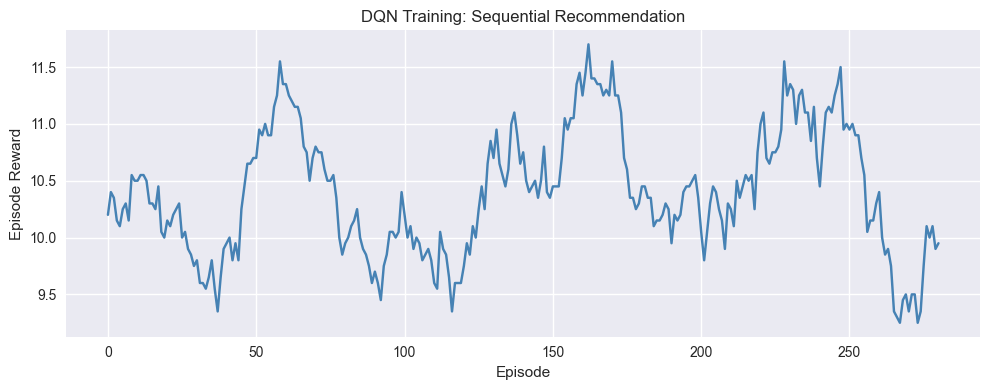

In [6]:
def train_dqn(env, policy_net, target_net, optimizer, replay_buffer,
              n_episodes: int = 300, gamma: float = 0.99, 
              epsilon_start: float = 1.0, epsilon_end: float = 0.05,
              batch_size: int = 64, target_update: int = 10):
    """Train DQN agent on sequential recommendation."""
    episode_rewards = []
    epsilon = epsilon_start
    epsilon_decay = (epsilon_start - epsilon_end) / (n_episodes * 0.8)
    
    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0.0
        done = False
        
        while not done:
            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = random.randint(0, env.n_items - 1)
            else:
                with torch.no_grad():
                    q_values = policy_net(torch.FloatTensor(state))
                    action = int(q_values.argmax())
            
            next_state, reward, done = env.step(action)
            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
            
            # Train
            if len(replay_buffer) >= batch_size:
                batch = replay_buffer.sample(batch_size)
                states = torch.FloatTensor(np.array([t.state for t in batch]))
                actions = torch.LongTensor([t.action for t in batch])
                rewards = torch.FloatTensor([t.reward for t in batch])
                next_states = torch.FloatTensor(np.array([t.next_state for t in batch]))
                dones = torch.FloatTensor([t.done for t in batch])
                
                current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(next_states).max(1)[0]
                    target_q = rewards + gamma * next_q * (1 - dones)
                
                loss = F.mse_loss(current_q, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        
        episode_rewards.append(total_reward)
        epsilon = max(epsilon_end, epsilon - epsilon_decay)
        
        # Update target network
        if (episode + 1) % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())
        
        if (episode + 1) % 50 == 0:
            avg_r = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1:4d} | Avg reward: {avg_r:.2f} | Epsilon: {epsilon:.3f}")
    
    return episode_rewards

episode_rewards = train_dqn(env, policy_net, target_net, optimizer, replay_buffer, n_episodes=300)

# Plot training progress
fig, ax = plt.subplots(figsize=(10, 4))
window = 20
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
ax.plot(smoothed, color='steelblue')
ax.set_xlabel("Episode")
ax.set_ylabel("Episode Reward")
ax.set_title("DQN Training: Sequential Recommendation")
plt.tight_layout()
plt.show()

## 5. Policy Gradient: REINFORCE for Ranking

Instead of learning Q-values, **policy gradient** methods directly parameterize the policy $\pi_\theta(a|s)$ and optimize it via gradient ascent on expected reward:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\left[\sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

where $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ is the return from time $t$.

For recommendation ranking, the policy outputs a **probability distribution over items** and we sample from it.

> **🔑 Pro Tip:** REINFORCE with a baseline $b(s)$ reduces variance: $\nabla_\theta J \propto \nabla_\theta \log \pi_\theta(a|s)(G_t - b(s_t))$. A common baseline is the running average of returns.

In [7]:
class REINFORCERecAgent(nn.Module):
    """REINFORCE policy gradient agent for recommendation."""
    
    def __init__(self, state_dim: int, n_items: int, hidden_dim: int = 64):
        super().__init__()
        self.policy = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_items)
        )
        self.saved_log_probs = []
        self.rewards = []
    
    def forward(self, state: torch.Tensor) -> torch.distributions.Categorical:
        logits = self.policy(state)
        return torch.distributions.Categorical(logits=logits)
    
    def select_action(self, state: np.ndarray) -> int:
        state_t = torch.FloatTensor(state)
        dist = self.forward(state_t)
        action = dist.sample()
        self.saved_log_probs.append(dist.log_prob(action))
        return int(action)


def train_reinforce(env, agent, optimizer, n_episodes: int = 500, gamma: float = 0.99):
    """Train REINFORCE agent with baseline."""
    episode_rewards = []
    baseline = 0.0
    
    for episode in range(n_episodes):
        state = env.reset()
        agent.saved_log_probs = []
        agent.rewards = []
        done = False
        
        while not done:
            action = agent.select_action(state)
            state, reward, done = env.step(action)
            agent.rewards.append(reward)
        
        total_reward = sum(agent.rewards)
        episode_rewards.append(total_reward)
        
        # Compute returns
        returns = []
        G = 0
        for r in reversed(agent.rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.FloatTensor(returns)
        
        # Normalize returns (acts as baseline)
        if returns.std() > 1e-8:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # Policy gradient
        policy_loss = []
        for log_prob, G in zip(agent.saved_log_probs, returns):
            policy_loss.append(-log_prob * G)
        
        optimizer.zero_grad()
        loss = torch.stack(policy_loss).sum()
        loss.backward()
        optimizer.step()
        
        if (episode + 1) % 100 == 0:
            avg_r = np.mean(episode_rewards[-50:])
            print(f"Episode {episode+1:4d} | Avg reward: {avg_r:.2f}")
    
    return episode_rewards


# Train REINFORCE
env_pg = SequentialRecEnv(n_users=100, n_items=50, seed=42)
reinforce_agent = REINFORCERecAgent(state_dim=state_dim, n_items=50)
pg_optimizer = optim.Adam(reinforce_agent.parameters(), lr=1e-3)

pg_rewards = train_reinforce(env_pg, reinforce_agent, pg_optimizer, n_episodes=500)

Episode  100 | Avg reward: 9.86


Episode  200 | Avg reward: 10.68


Episode  300 | Avg reward: 10.00


Episode  400 | Avg reward: 10.20


Episode  500 | Avg reward: 9.94


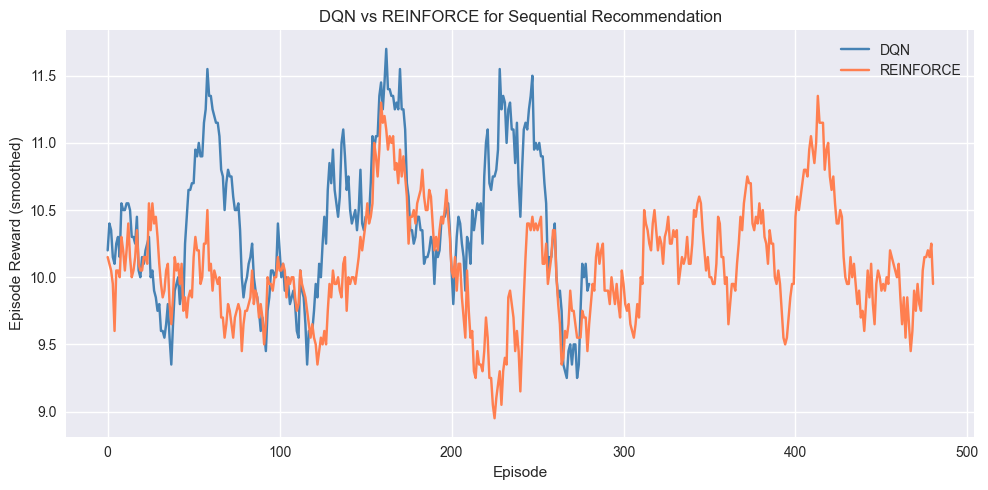

In [8]:
# Compare DQN vs REINFORCE
fig, ax = plt.subplots(figsize=(10, 5))
window = 20

dqn_smooth = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
pg_smooth = np.convolve(pg_rewards, np.ones(window)/window, mode='valid')

ax.plot(dqn_smooth, label='DQN', color='steelblue')
ax.plot(pg_smooth, label='REINFORCE', color='coral')
ax.set_xlabel("Episode")
ax.set_ylabel("Episode Reward (smoothed)")
ax.set_title("DQN vs REINFORCE for Sequential Recommendation")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Off-Policy Evaluation (OPE)

In production, we cannot deploy a new policy and see its effect immediately. **Off-Policy Evaluation** estimates the performance of a new policy $\pi$ using data collected by a different policy $\mu$ (the logging policy).

### Importance Sampling (IS)

$$\hat{V}_{IS}(\pi) = \frac{1}{n} \sum_{i=1}^{n} \frac{\pi(a_i|s_i)}{\mu(a_i|s_i)} r_i$$

### Doubly Robust (DR) Estimator

Combines a reward model $\hat{r}(s, a)$ with importance sampling (Dudik et al., 2011):

$$\hat{V}_{DR}(\pi) = \frac{1}{n} \sum_{i=1}^{n} \left[\hat{r}(s_i, \pi) + \frac{\pi(a_i|s_i)}{\mu(a_i|s_i)}(r_i - \hat{r}(s_i, a_i))\right]$$

> **💡 Concept:** The DR estimator is "doubly robust" because it is consistent if either the reward model or the importance weights are correct. This makes it more reliable in practice.

In [9]:
class OPEEvaluator:
    """Off-Policy Evaluation for recommendation policies."""
    
    @staticmethod
    def importance_sampling(logged_data, target_policy_probs, logging_policy_probs):
        """Standard Importance Sampling estimator."""
        rewards = np.array([d['reward'] for d in logged_data])
        weights = target_policy_probs / (logging_policy_probs + 1e-10)
        # Clip weights for stability
        weights = np.clip(weights, 0, 10)
        return np.mean(weights * rewards)
    
    @staticmethod
    def self_normalized_is(logged_data, target_policy_probs, logging_policy_probs):
        """Self-Normalized Importance Sampling (lower variance)."""
        rewards = np.array([d['reward'] for d in logged_data])
        weights = target_policy_probs / (logging_policy_probs + 1e-10)
        weights = np.clip(weights, 0, 10)
        return np.sum(weights * rewards) / (np.sum(weights) + 1e-10)
    
    @staticmethod
    def doubly_robust(logged_data, target_policy_probs, logging_policy_probs,
                      reward_model_preds, target_expected_reward):
        """Doubly Robust estimator (Dudik et al., 2011)."""
        rewards = np.array([d['reward'] for d in logged_data])
        weights = target_policy_probs / (logging_policy_probs + 1e-10)
        weights = np.clip(weights, 0, 10)
        
        dr_estimates = target_expected_reward + weights * (rewards - reward_model_preds)
        return np.mean(dr_estimates)


# Simulate logged data from a random policy
np.random.seed(42)
n_samples = 2000
n_items = 10
true_ctrs = np.array([0.05, 0.08, 0.12, 0.15, 0.20, 0.10, 0.07, 0.03, 0.18, 0.25])

# Logging policy: uniform random
logging_probs = np.ones(n_items) / n_items

logged_data = []
for i in range(n_samples):
    action = np.random.choice(n_items)
    reward = float(np.random.random() < true_ctrs[action])
    logged_data.append({'action': action, 'reward': reward})

actions = np.array([d['action'] for d in logged_data])

# Target policy: recommend top-3 items equally
top3 = np.argsort(true_ctrs)[-3:]
target_probs_per_item = np.zeros(n_items)
target_probs_per_item[top3] = 1.0 / 3.0

target_probs = target_probs_per_item[actions]
log_probs = logging_probs[actions]

# Reward model (imperfect): add noise to true CTRs
reward_model = true_ctrs + np.random.randn(n_items) * 0.02
reward_model_preds = reward_model[actions]
target_expected = np.sum(target_probs_per_item * reward_model)

# True value of target policy
true_value = np.sum(target_probs_per_item * true_ctrs)

evaluator = OPEEvaluator()
is_estimate = evaluator.importance_sampling(logged_data, target_probs, log_probs)
snis_estimate = evaluator.self_normalized_is(logged_data, target_probs, log_probs)
dr_estimate = evaluator.doubly_robust(logged_data, target_probs, log_probs,
                                       reward_model_preds, target_expected)

print(f"True value of target policy:     {true_value:.4f}")
print(f"Importance Sampling estimate:     {is_estimate:.4f}")
print(f"Self-Normalized IS estimate:      {snis_estimate:.4f}")
print(f"Doubly Robust estimate:           {dr_estimate:.4f}")

# Variance analysis with bootstrap
n_bootstrap = 200
is_estimates = []
snis_estimates = []
dr_estimates = []

for _ in range(n_bootstrap):
    idx = np.random.choice(n_samples, n_samples, replace=True)
    boot_data = [logged_data[i] for i in idx]
    boot_tp = target_probs[idx]
    boot_lp = log_probs[idx]
    boot_rmp = reward_model_preds[idx]
    
    is_estimates.append(evaluator.importance_sampling(boot_data, boot_tp, boot_lp))
    snis_estimates.append(evaluator.self_normalized_is(boot_data, boot_tp, boot_lp))
    dr_estimates.append(evaluator.doubly_robust(boot_data, boot_tp, boot_lp, boot_rmp, target_expected))

print(f"\nVariance (bootstrap):")
print(f"  IS:   {np.var(is_estimates):.6f}")
print(f"  SNIS: {np.var(snis_estimates):.6f}")
print(f"  DR:   {np.var(dr_estimates):.6f}")

True value of target policy:     0.2100
Importance Sampling estimate:     0.2017
Self-Normalized IS estimate:      0.2017
Doubly Robust estimate:           0.2044



Variance (bootstrap):
  IS:   0.000270
  SNIS: 0.000230
  DR:   0.000224


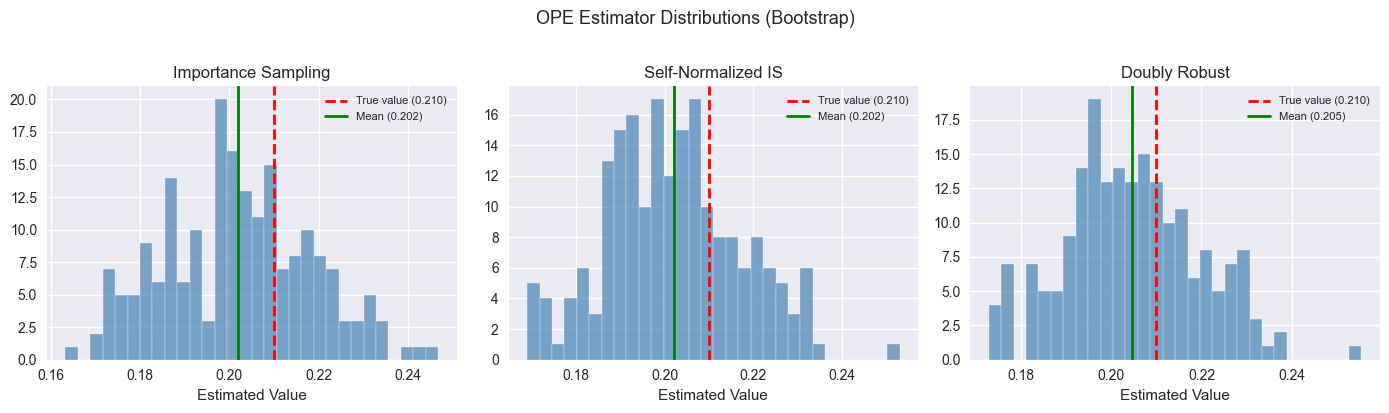

In [10]:
# Visualize OPE estimator distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, estimates, name in zip(axes, 
                                [is_estimates, snis_estimates, dr_estimates],
                                ['Importance Sampling', 'Self-Normalized IS', 'Doubly Robust']):
    ax.hist(estimates, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(true_value, color='red', linestyle='--', linewidth=2, label=f'True value ({true_value:.3f})')
    ax.axvline(np.mean(estimates), color='green', linestyle='-', linewidth=2, label=f'Mean ({np.mean(estimates):.3f})')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_xlabel('Estimated Value')

plt.suptitle('OPE Estimator Distributions (Bootstrap)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary

| Approach | Context? | Sequential? | Key Strength | Key Weakness |
|----------|----------|-------------|-------------|-------------|
| Epsilon-Greedy | No | No | Simple | Linear regret |
| UCB | No | No | Theoretical guarantees | Conservative |
| Thompson Sampling | No | No | Optimal in practice | Posterior computation |
| Contextual Bandits | Yes | No | Personalized exploration | No long-term planning |
| DQN | Yes | Yes | Long-term optimization | Large action space |
| REINFORCE | Yes | Yes | Direct policy optimization | High variance |

**Key references:**
- Auer et al. (2002) - UCB1 algorithm
- Li et al. (2010) - LinUCB for Yahoo! News (contextual bandits)
- Chapelle & Li (2011) - Thompson Sampling empirical study
- Mnih et al. (2015) - DQN (DeepMind)
- Dudik et al. (2011) - Doubly robust OPE

---

## Exercises

### 🏋️ Exercise 1: Thompson Sampling for News Recommendation

Implement Thompson Sampling for a news recommendation scenario where articles have different CTRs for different user segments.

In [11]:
# 🏋️ Exercise 1: Thompson Sampling for News Recommendation
#
# Scenario: 5 news categories, 3 user segments. Each segment has different
# preferences. Implement per-segment Thompson Sampling.

class SegmentedThompsonSampling:
    """Thompson Sampling with separate posteriors per user segment."""
    
    def __init__(self, n_segments: int, n_items: int):
        self.n_segments = n_segments
        self.n_items = n_items
        # TODO: Initialize alpha and beta arrays for each segment-item pair
        # Shape should be (n_segments, n_items)
        self.alphas = np.ones((n_segments, n_items))
        self.betas = np.ones((n_segments, n_items))
    
    def select_arm(self, segment: int) -> int:
        # TODO: Sample from Beta distribution for the given segment
        # and return the arm with highest sample
        pass
    
    def update(self, segment: int, arm: int, reward: float):
        # TODO: Update the Beta posterior for the segment-arm pair
        pass


# Test environment
true_ctrs_by_segment = np.array([
    [0.20, 0.05, 0.10, 0.15, 0.03],  # Segment 0: likes politics
    [0.05, 0.25, 0.08, 0.03, 0.12],  # Segment 1: likes sports
    [0.08, 0.03, 0.22, 0.18, 0.10],  # Segment 2: likes tech
])

# TODO: Run the experiment for 2000 rounds
# - Randomly sample a user segment each round
# - Use SegmentedThompsonSampling to pick an article
# - Track per-segment regret
# - Plot cumulative regret over time

print("Exercise 1: Implement SegmentedThompsonSampling above")

Exercise 1: Implement SegmentedThompsonSampling above


### 🏋️ Exercise 2: Implement Decaying Epsilon-Greedy

Modify the epsilon-greedy strategy to decay epsilon over time and compare with fixed epsilon.

In [12]:
# 🏋️ Exercise 2: Decaying Epsilon-Greedy

class DecayingEpsilonGreedy:
    """Epsilon-greedy with epsilon decay schedule."""
    
    def __init__(self, n_items: int, epsilon_start: float = 1.0,
                 epsilon_min: float = 0.01, decay_rate: float = 0.995):
        self.n_items = n_items
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.decay_rate = decay_rate
        self.counts = np.zeros(n_items)
        self.values = np.zeros(n_items)
    
    def select_arm(self) -> int:
        # TODO: Implement epsilon-greedy selection with current epsilon
        pass
    
    def update(self, arm: int, reward: float):
        # TODO: Update arm value estimate AND decay epsilon
        pass

# TODO: Compare DecayingEpsilonGreedy with fixed EpsilonGreedy(0.1)
# Run both for 5000 rounds and plot cumulative regret

print("Exercise 2: Implement DecayingEpsilonGreedy above")

Exercise 2: Implement DecayingEpsilonGreedy above


### 🏋️ Exercise 3: DQN with Prioritized Experience Replay

Improve the DQN agent by implementing prioritized experience replay, where transitions with higher TD error are sampled more frequently.

In [13]:
# 🏋️ Exercise 3: Prioritized Experience Replay

class PrioritizedReplayBuffer:
    """Replay buffer that samples based on TD-error priority."""
    
    def __init__(self, capacity: int = 10000, alpha: float = 0.6):
        self.capacity = capacity
        self.alpha = alpha  # Priority exponent
        self.buffer = []
        self.priorities = []
        self.position = 0
    
    def push(self, state, action, reward, next_state, done, td_error: float = 1.0):
        # TODO: Store transition with priority based on td_error
        pass
    
    def sample(self, batch_size: int, beta: float = 0.4):
        # TODO: Sample batch with probability proportional to priority^alpha
        # Return transitions and importance sampling weights
        pass
    
    def update_priorities(self, indices, td_errors):
        # TODO: Update priorities after training
        pass

# TODO: Train DQN with PrioritizedReplayBuffer and compare with uniform replay

print("Exercise 3: Implement PrioritizedReplayBuffer above")

Exercise 3: Implement PrioritizedReplayBuffer above


### 🏋️ Exercise 4: OPE Comparison Study

Run a comprehensive comparison of OPE methods with varying amounts of logged data.

In [14]:
# 🏋️ Exercise 4: OPE with varying data sizes

# TODO: For data sizes [100, 500, 1000, 2000, 5000]:
#   1. Generate logged data from uniform random policy
#   2. Evaluate IS, SNIS, and DR estimators
#   3. Use bootstrap to compute bias and variance for each estimator
#   4. Plot bias^2, variance, and MSE as a function of data size

data_sizes = [100, 500, 1000, 2000, 5000]
# TODO: Fill in the experiment

print("Exercise 4: Complete the OPE comparison study above")

Exercise 4: Complete the OPE comparison study above
